# Prepare street network for routing analysis

This notebook prepares the street network used for analysing routes to schools.

The network is derived from OpenStreetMap data and will later be used to compute routes and accessibility between homes and schools.

## Load the libraries needed for network preparation

Here we import the libraries needed to load spatial layers, work with OpenStreetMap data, and visualize the network.

In [2]:
import pandas as pd
import geopandas as gpd
import osmnx as ox
import matplotlib.pyplot as plt

## Load the official school district polygons

Here we load the official district polygons that define the study area.

These polygons will be merged into one municipality-wide boundary and used to download the street network.

In [3]:
schools = gpd.read_file(
    "../data/processed/core_layers.gpkg",
    layer="schools"
)

districts = gpd.read_file(
    "../data/processed/core_layers.gpkg",
    layer="school_districts"
)

In [4]:
districts.head()

,temakode,temanavn,objekt_id,versions_i,systid_fra,systid_til,oprettet,cvr_kode,cvr_navn,kommunekod,...,starttrin,sluttrin_k,slutttrin,sagsnr,link,udd_hovedo,udd_hove_1,udd_delomr,udd_delo_1,geometry
0,5710,t_5710_born_skole_dis_t,caebf878-f997-11ea-8ef4-06d09fa510f4,4af5ce08-a358-11f0-888f-31f687df6650,2025-10-07,NaN,2020-09-18,64942212,Københavns Kommune,101,...,0. klasse,9,9. klasse,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((724468.727 6174207.618, 724824.483 6..."
1,5710,t_5710_born_skole_dis_t,caec40da-f997-11ea-8efa-06d09fa510f4,4af9587a-a358-11f0-888f-31f687df6650,2025-10-07,NaN,2020-09-18,64942212,Københavns Kommune,101,...,0. klasse,9,9. klasse,NaN,NaN,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((723566.615 6172586.107, 723670..."
2,5710,t_5710_born_skole_dis_t,caf771da-f997-11ea-8f2a-06d09fa510f4,4afad1e6-a358-11f0-888f-31f687df6650,2025-10-07,NaN,2020-09-18,64942212,Københavns Kommune,101,...,0. klasse,9,9. klasse,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((724798.236 6169075.917, 724761.682 6..."
3,5710,t_5710_born_skole_dis_t,cae99b50-f997-11ea-8eca-06d09fa510f4,4afbefd6-a358-11f0-888f-31f687df6650,2025-10-07,NaN,2020-09-18,64942212,Københavns Kommune,101,...,0. klasse,9,9. klasse,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((723570.181 6175053.926, 723568.928 6..."
4,5710,t_5710_born_skole_dis_t,caf6d3e2-f997-11ea-8f20-06d09fa510f4,4afd1a5a-a358-11f0-888f-31f687df6650,2025-10-07,NaN,2020-09-18,64942212,Københavns Kommune,101,...,0. klasse,9,9. klasse,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((724592.495 6177975.285, 724787.236 6..."


## Merge the district polygons into one study area

Here we combine all school district polygons into one geometry representing the overall study area.

This boundary will be used to request the bike network from OpenStreetMap.

In [5]:
study_area = districts.dissolve()
study_area

/Users/peterkriegel/Documents/ITU/2026/Researchproject/safe-school-paths-cph/.pixi/envs/default/lib/python3.9/site-packages/shapely/set_operations.py:426: RuntimeWarning: invalid value encountered in unary_union
  return lib.unary_union(collections, **kwargs)


,geometry,temakode,temanavn,objekt_id,versions_i,systid_fra,systid_til,oprettet,cvr_kode,cvr_navn,...,starttrin_,starttrin,sluttrin_k,slutttrin,sagsnr,link,udd_hovedo,udd_hove_1,udd_delomr,udd_delo_1
0,"MULTIPOLYGON (((721535.268 6171337.076, 720874...",5710,t_5710_born_skole_dis_t,caebf878-f997-11ea-8ef4-06d09fa510f4,4af5ce08-a358-11f0-888f-31f687df6650,2025-10-07,NaN,2020-09-18,64942212,Københavns Kommune,...,11,0. klasse,9,9. klasse,NaN,NaN,NaN,NaN,NaN,NaN


## Convert the study area to WGS84

OSMnx expects the boundary geometry in latitude/longitude coordinates.

Here we convert the study area to EPSG:4326 before downloading the network.

In [6]:
study_area_wgs84 = study_area.to_crs(4326)

In [7]:
study_area_wgs84

,geometry,temakode,temanavn,objekt_id,versions_i,systid_fra,systid_til,oprettet,cvr_kode,cvr_navn,...,starttrin_,starttrin,sluttrin_k,slutttrin,sagsnr,link,udd_hovedo,udd_hove_1,udd_delomr,udd_delo_1
0,"MULTIPOLYGON (((12.52000 55.63733, 12.50923 55...",5710,t_5710_born_skole_dis_t,caebf878-f997-11ea-8ef4-06d09fa510f4,4af5ce08-a358-11f0-888f-31f687df6650,2025-10-07,NaN,2020-09-18,64942212,Københavns Kommune,...,11,0. klasse,9,9. klasse,NaN,NaN,NaN,NaN,NaN,NaN


## Extract the polygon geometry

The dissolved study area is stored as a GeoDataFrame. Here we extract the polygon geometry itself so it can be used directly in OSMnx.

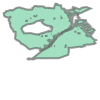

In [8]:
polygon = study_area_wgs84.geometry.iloc[0]
polygon

## We need to define which tags is useful to get from OSM

In [9]:
ox.settings.useful_tags_way = [
    "highway",
    "cycleway",
    "cycleway:left",
    "cycleway:right",
    "bicycle",
    "maxspeed",
    "surface",
    "name",
    "oneway",
    "access",
    "vehicle",
    "motor_vehicle",
    "motorcar"
]

## Download the bike network within the study area

Here we download the bike network from OpenStreetMap using the study area polygon rather than a place name.

In [10]:
G = ox.graph_from_polygon(
    polygon,
    network_type="bike"
)

/Users/peterkriegel/Documents/ITU/2026/Researchproject/safe-school-paths-cph/.pixi/envs/default/lib/python3.9/site-packages/shapely/constructive.py:181: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/Users/peterkriegel/Documents/ITU/2026/Researchproject/safe-school-paths-cph/.pixi/envs/default/lib/python3.9/site-packages/shapely/predicates.py:798: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/Users/peterkriegel/Documents/ITU/2026/Researchproject/safe-school-paths-cph/.pixi/envs/default/lib/python3.9/site-packages/shapely/set_operations.py:340: RuntimeWarning: invalid value encountered in union
  return lib.union(a, b, **kwargs)
/Users/peterkriegel/Documents/ITU/2026/Researchproject/safe-school-paths-cph/.pixi/envs/default/lib/python3.9/site-packages/shapely/predicates.py:798: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/Users/peterkriegel/Documents/ITU/2026/

## Check the size of the network

In [11]:
len(G.nodes), len(G.edges)

(22298, 54170)

## Plot the downloaded bike network

Here we make a quick plot of the network to visually check whether it looks like a realistic street network for Copenhagen.

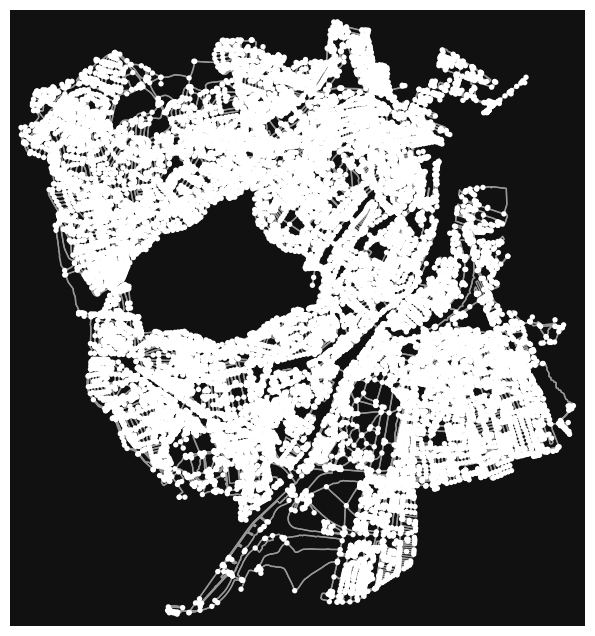

In [12]:
fig, ax = ox.plot_graph(G)

## Convert the graph into GeoDataFrames

Here we convert the network graph into node and edge GeoDataFrames so the road segments can be plotted together with schools and districts.

In [13]:
nodes, edges = ox.graph_to_gdfs(G)

## Reproject the network to the common project CRS

The schools and district polygons are already stored in EPSG:25832.

Here we convert the network layers to the same CRS so they can be overlaid directly.

In [14]:
edges = edges.to_crs(25832)
nodes = nodes.to_crs(25832)

## Plot the network together with districts and schools

This map is used as a visual sanity check to confirm that the road network, school district polygons, and school locations line up correctly.

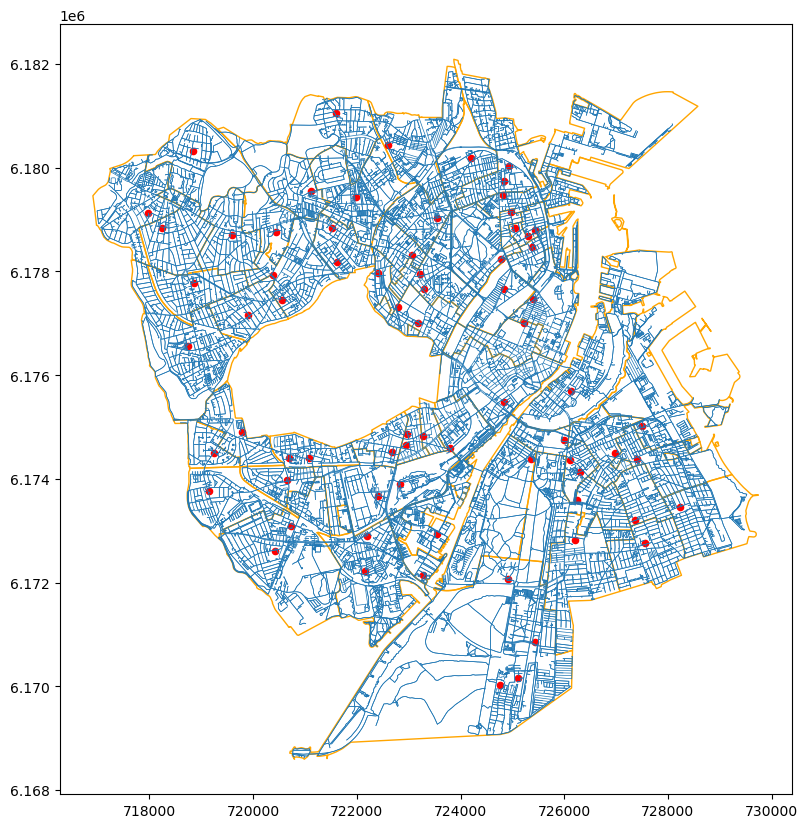

In [15]:
ax = edges.plot(figsize=(10, 10), linewidth=0.5)
districts.plot(ax=ax, edgecolor="orange", facecolor="none")
schools.plot(ax=ax, color="red", markersize=20)

plt.show()

## Save the prepared network

Finally we save the downloaded bike network so it can be reused later without downloading it again.

In [16]:
ox.save_graphml(G, "../data/processed/cph_bike_network.graphml")

## We want to look at the different tags the edges hold

### INspect available edge attributes

Before denining safe cycling paths, we inspect shich OSM tags are available in the edges.

These attributes describe the road segments and include information such as surface, maxspeed, cycleway.

In [17]:
edges.columns.to_list()

['osmid',
 'highway',
 'cycleway:left',
 'cycleway:right',
 'maxspeed',
 'surface',
 'name',
 'oneway',
 'reversed',
 'length',
 'bicycle',
 'geometry',
 'cycleway',
 'access',
 'motor_vehicle',
 'vehicle',
 'motorcar']

## We want to inspect the actual values in the different tags

### Explore road types in the network

The highway tag is the main OSM attribute used to secribe what kind of road or path each edge represents.

Inspecting its most frequent values helps identify which street and path types are most common in the network.

In [18]:
edges["highway"].value_counts().head(20)

highway
residential                     18162
service                         17142
tertiary                         6434
path                             4392
cycleway                         3696
unclassified                     1144
primary                           598
living_street                     572
pedestrian                        538
secondary                         208
[path, service]                   158
[service, residential]            143
track                             138
[path, residential]               135
[cycleway, residential]           113
tertiary_link                      87
[residential, living_street]       72
[pedestrian, residential]          50
busway                             48
[cycleway, service]                42
Name: count, dtype: int64

### Explore the general cycling infrastructure tags

The cycleway tag descibes whether a road segment has cycling infrastructure attached to it, such as a lane or a track.

Inspecting these values helps identify how protected bike paths are represented in the data.

In [19]:
edges["cycleway"].value_counts().head(20)

cycleway
track                              4059
no                                 1921
separate                            505
lane                                265
crossing                            202
shared_lane                          16
shared                               14
[track, no]                          12
[lane, track]                         6
construction                          3
[lane, no]                            3
[shared, no]                          2
opposite_track                        2
opposite                              2
link                                  1
designated                            1
[shared, crossing, shared_lane]       1
[crossing, shared, shared_lane]       1
[crossing, designated]                1
opposite_lane                         1
Name: count, dtype: int64

### Explore the left-side cycling infrastructure

Some roads store cycling infrastructure seperately for the left and right side of the carriageway.

Here we inspect the values on the left side to understand how side-specific bicycle facilities are encoded.

In [20]:
edges["cycleway:left"].value_counts().head(20)

cycleway:left
no                         1058
separate                    234
track                       222
lane                        131
use_sidepath                 24
opposite_track               11
opposite_lane                11
[lane, track]                 7
[track, no]                   2
shared_lane                   2
[shared_lane, lane]           2
[no, separate]                2
[lane, no]                    1
[track, opposite_track]       1
Name: count, dtype: int64

### Explore the right-side cycling infrastructure

We do the same as the cell above, just for the right cycleway attribute.

In [21]:
edges["cycleway:right"].value_counts().head(20)

cycleway:right
track                         1498
separate                       695
no                             340
lane                           254
shared_lane                     90
[lane, track]                   28
[shared_lane, track]            15
share_busway                     8
[shared_lane, no]                4
shoulder                         4
[track, no]                      3
[no, separate]                   3
[track, separate]                2
[lane, no]                       2
use_sidepath                     2
[shared_lane, lane]              2
[shared_lane, lane, track]       1
Name: count, dtype: int64

### Explore bicycle access tags

The bicycle tag describtes whether cuycling is allowed, designated, restricted or redireted.

This attribute helps interpret whether a road segment is intended to be uysed by cyclists.

In [22]:
edges["bicycle"].value_counts()

bicycle
yes                    2905
designated             2290
use_sidepath           1563
dismount                106
[yes, designated]        35
permissive               26
private                  14
destination               6
[yes, use_sidepath]       3
Name: count, dtype: int64

## Explore the motorvehicle attributes

These attributes give us insights if vehicles can access a road.

In [23]:
edges["access"].value_counts(dropna=False).head(20)

access
NaN                         53516
no                            283
destination                   168
customers                      92
yes                            61
delivery                       19
permit                         15
permissive                     12
[destination, customers]        2
unknown                         2
Name: count, dtype: int64

In [24]:
edges["vehicle"].value_counts(dropna=False).head(20)

vehicle
NaN         54064
yes            94
no             10
delivery        2
Name: count, dtype: int64

In [25]:
edges["motor_vehicle"].value_counts(dropna=False).head(20)

motor_vehicle
NaN                          53030
no                             378
destination                    294
yes                            154
private                        133
permissive                      75
permit                          73
designated                      14
delivery                         5
[yes, destination]               4
[yes, private]                   2
[yes, no]                        2
[destination, designated]        2
[private, no]                    2
[destination, private]           2
Name: count, dtype: int64

In [26]:
edges["motorcar"].value_counts(dropna=False).head(20)

motorcar
NaN        54080
yes           51
no            29
private       10
Name: count, dtype: int64

## Build a weighted safety model

Uo to this point, we have mainly looked at the network as either safe or not safe. 

Now we want to make the model a bit more realistic by giving different road types, different safety weights.

This idea is:

- weight 1 = safest roads
- weight 5 = fairly safe roads
- weight 10 = less safe roads
- weight 20 = least safe roads

Later these weights will be combined with road length, so the routing model prefers safer roads but still takes distance into account.

## Helper function for OSM tags

Some OSM attributes are stored as single values, while others are stored as lists.

This helper function makes it easier to check whether an edge contains a vertain value no matter which format the tag is stored in.

In [27]:
def has_value(x, valid_values):
    if isinstance(x, list):
        return any(v in valid_values for v in x)
    return x in valid_values

## Turn speed limits into numbers

The maxspeed tag can be stored in different ways, so here we turn it into a numeric column.

That makes it easier to use speed in the safety classification.

In [28]:
def parse_maxspeed(x):
    if isinstance(x, list):
        x = x[0]
    if isinstance(x, (int, float)):
        return x
    if isinstance(x, str):
        digits = "".join(ch for ch in x if ch.isdigit())
        if digits:
            return float(digits)
    return None

edges["maxspeed_num"] = edges["maxspeed"].apply(parse_maxspeed)

## Defining the safety groups

Here we split the network into four safety levels as mentioned above.

This is still a simplified model, but it is more flexible than a strict safe / unsafe split.

In [29]:
protected_cycleway_values = {
    "track",
    "opposite_track"
}

protected_highway_values = {
    "cycleway"
}

calm_street_values = {
    "living_street",
    "residential",
    "unclassified"
}

service_values = {
    "service"
}

## Assigning one safety weight to each road segment

This function gives every edge a safety weight.

In [30]:
def assign_safety_weight(row):
    highway = row["highway"]
    cycleway = row["cycleway"]
    cycleway_left = row["cycleway:left"]
    cycleway_right = row["cycleway:right"]
    bicycle = row["bicycle"]
    maxspeed = row["maxspeed_num"]

    access = row.get("access")
    vehicle = row.get("vehicle")
    motor_vehicle = row.get("motor_vehicle")
    motorcar = row.get("motorcar")

    is_protected = (
        has_value(highway, protected_highway_values) or
        has_value(cycleway, protected_cycleway_values) or
        has_value(cycleway_left, protected_cycleway_values) or
        has_value(cycleway_right, protected_cycleway_values)
    )
    if is_protected:
        return 1

    cars_explicitly_not_allowed = (
        has_value(vehicle, {"no"}) or
        has_value(motor_vehicle, {"no"}) or
        has_value(motorcar, {"no"})
    )

    is_safe_path = (
    has_value(highway, {"path"}) and
    not has_value(bicycle, {"dismount", "private"}) and
    not has_value(vehicle, {"yes"}) and
    not has_value(motor_vehicle, {"yes"}) and
    not has_value(motorcar, {"yes"})
)
    
    if is_safe_path:
        return 1

    if has_value(bicycle, {"dismount", "private"}):
        return 20

    is_calm_street = has_value(highway, calm_street_values) and (
        pd.isna(maxspeed) or maxspeed <= 30
    )
    if is_calm_street:
        return 5

    is_service_road = has_value(highway, service_values)
    if is_service_road:
        return 10

    return 20

## Create the safety weight column

Now we apply the safety function to all edges in the network.

After this, every road segment has a safety weight that can later be used for routing.

In [31]:
edges["safety_weight"] = edges.apply(assign_safety_weight, axis=1)

## Adding readible safety labels

The numeric weights are useful for routing, biut it is also nice to have a text label for checking and plotting.

In [32]:
def weight_to_label(weight):
    if weight == 1:
        return "protected"
    elif weight == 5:
        return "calm_street"
    elif weight == 10:
        return "service_road"
    else:
        return "least_safe"

edges["safety_class"] = edges["safety_weight"].apply(weight_to_label)

## Bulid the routing cost

For routing, we do not want to use the safety weight alone.

A road segment should become more expensive both when it is longer and when it is less safe.

So the routing cost is: 

cost = length x safety weight

This means the model will prefer safer roads, but it still cares about distance.

In [33]:
edges["routing_cost"] = edges["length"] * edges["safety_weight"]

## Quick check of the weighted model

Before going further, we check how many edges end up in each safety class and what the first few rows look like.

In [34]:
print(edges["safety_class"].value_counts())
print()
print(
    edges[
        [
            "highway",
            "bicycle",
            "access",
            "vehicle",
            "motor_vehicle",
            "motorcar",
            "cycleway",
            "cycleway:left",
            "cycleway:right",
            "maxspeed",
            "maxspeed_num",
            "safety_weight",
            "safety_class"
        ]
    ].head(20)
)

safety_class
service_road    17265
least_safe      16066
protected       14460
calm_street      6379
Name: count, dtype: int64

                             highway       bicycle access vehicle  \
u      v           key                                              
118725 12541976804 0        tertiary           NaN    NaN     NaN   
       2378383724  0        tertiary  use_sidepath    NaN     NaN   
118730 12652971293 0         primary  use_sidepath    NaN     NaN   
118732 6534097568  0        tertiary  use_sidepath    NaN     NaN   
       283603631   0    primary_link  use_sidepath    NaN     NaN   
118735 92994313    0        tertiary           NaN    NaN     NaN   
       6511276293  0         primary  use_sidepath    NaN     NaN   
118738 588481119   0        tertiary  use_sidepath    NaN     NaN   
118744 1277939659  0         service           NaN    NaN     NaN   
                   1         service           NaN    NaN     NaN   
       1277939654  0         service        

## Taking the number of edges and transforming them into the total length of each class
To use for statistics or nummeric overview, we need the total length of edges in the classes instead of the total number. This is done below.

In [35]:
safety_length_table = (
    edges.groupby(["safety_class", "safety_weight"])
    .agg(
        total_length_m=("length", "sum"),
        number_of_edges=("length", "count")
    )
    .reset_index()
)

total_network_length = safety_length_table["total_length_m"].sum()

safety_length_table["share_percent"] = (
    safety_length_table["total_length_m"] / total_network_length * 100
)

safety_length_table = safety_length_table.sort_values("safety_weight")

safety_length_table

,safety_class,safety_weight,total_length_m,number_of_edges,share_percent
2,protected,1,993265.421,14460,30.128499
0,calm_street,5,442693.872,6379,13.428135
3,service_road,10,871387.763,17265,26.431611
1,least_safe,20,989416.616,16066,30.011754


In [36]:
safety_length_table_report = safety_length_table.copy()

safety_length_table_report["Safety class"] = safety_length_table_report.apply(
    lambda row: f"{row['safety_class'].replace('_', ' ').title()} ({int(row['safety_weight'])})",
    axis=1
)

safety_length_table_report["Total length (km)"] = (
    safety_length_table_report["total_length_m"] / 1000
).round(1)

safety_length_table_report["Share (%)"] = (
    safety_length_table_report["share_percent"]
).round(1)

safety_length_table_report = safety_length_table_report[
    ["Safety class", "Total length (km)", "Share (%)"]
]

safety_length_table_report

,Safety class,Total length (km),Share (%)
2,Protected (1),993.3,30.1
0,Calm Street (5),442.7,13.4
3,Service Road (10),871.4,26.4
1,Least Safe (20),989.4,30.0


## Splitting the network into groups for plotting

Here we make separate subsets so that we cna plot the different safety classes and see if the classification looks reasonable on the map.

In [37]:
protected_edges = edges[edges["safety_weight"] == 1].copy()
calm_edges = edges[edges["safety_weight"] == 5].copy()
service_edges = edges[edges["safety_weight"] == 10].copy()
least_safe_edges = edges[edges["safety_weight"] == 20].copy()

## Plot the weighted safety classes

This map is just a visual check. The goal is to see whether the weighted model roughly matches what we would expext, which is that protected cuycling infrastructure in one group, calmer local streets in another, and larger mixed traffic roads mainly in the least safe group.

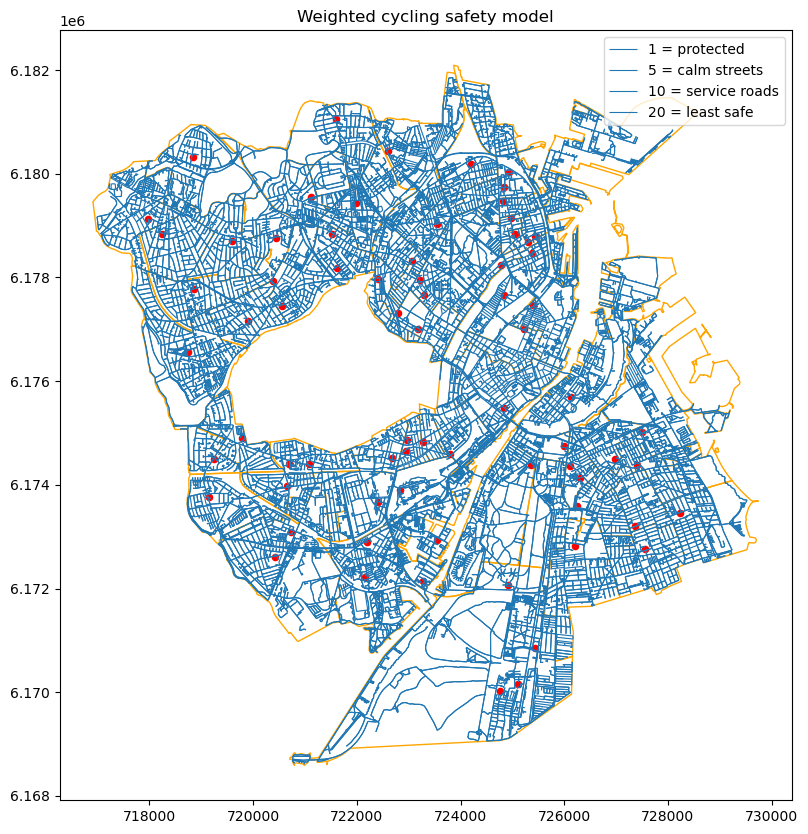

In [38]:
fig, ax = plt.subplots(figsize=(10, 10))

edges.plot(ax=ax, color="lightgrey", linewidth=0.3)
protected_edges.plot(ax=ax, linewidth=0.8, label="1 = protected")
calm_edges.plot(ax=ax, linewidth=0.8, label="5 = calm streets")
service_edges.plot(ax=ax, linewidth=0.8, label="10 = service roads")
least_safe_edges.plot(ax=ax, linewidth=0.8, label="20 = least safe")

districts.plot(ax=ax, edgecolor="orange", facecolor="none")
schools.plot(ax=ax, color="red", markersize=20)

plt.title("Weighted cycling safety model")
plt.legend()
plt.show()

## Make the node geometry match the x and y coordinates

Before rebuilding the graph, we make the node geometry match the x and y columns.

This helps avoid warnings when rebuilding the graph from the node and edge tables.

In [39]:
nodes = nodes.copy()
nodes["x"] = nodes.geometry.x
nodes["y"] = nodes.geometry.y

## Rebuild a weighted graph for later routing

The edge rable now contains the safety weights and routing cost.

To make later route analysis easier, we rebuild the graph from the node and edge tables so that weighted rotuing attributes are stored directly in the graph

In [40]:
G_weighted = ox.graph_from_gdfs(nodes, edges)

## Save the weighted graph

This graph can be loaded in the routing notebook and used for both shortest path routing and weighted safest-path routing

In [41]:
ox.save_graphml(G_weighted, "../data/processed/cph_bike_network_weighted.graphml")

### Prepare edge attributes for export

Some OSM attributes are stored as lists, but GeoPackage formal does not support list-type values.
So here we make a copy of the edge table just for export, and convert any list-type values into strings before saving.

In [42]:
edges_export = edges.copy()

for col in edges_export.columns:
    if edges_export[col].apply(lambda x: isinstance(x, list)).any():
        edges_export[col] = edges_export[col].astype(str)

## Save the weighted network edges

Now we save the updated edge layer, so that the routing notebooks can reuse the safety weights and routing cost without having to reuild them every time.

In [43]:
edges_export.to_file(
    "../data/processed/network_layers.gpkg",
    layer="bike_edges_weighted",
    driver="GPKG"
)

## Save the nodes

We also save the node layer

In [44]:
nodes.to_file(
    "../data/processed/network_layers.gpkg",
    layer="bike_nodes",
    driver="GPKG"
)